<a href="https://colab.research.google.com/github/GiorgiaTrabucco/Kniffel/blob/main/KniffelG.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Kniffel
The game of Kniffel is played with 5 dice with 6 sides numbered from 1 to 6 all rolled at once.
This code determines the distribution of the number of rolls it takes to achieve six special combinations in total:


1.   the dice show (1, 2, 3, 4, 5),
2.   they show (2, 3, 4, 5, 6),
3.   they all show the same number (this is called a kniffel),
4.   only 4 of them show the same number,
5.   3 of them show the same number and the remaining 2 show another number [this is a full house, e.g., (2, 2, 2, 5, 5)],
6.   only 3 of them show the same number.

Procedure:
* Simulate a fair roll of the five dice.
* Check whether a special combination was produced.

In [4]:
from random import randrange
import matplotlib.pyplot as plt

In [5]:
#Initialization
ndice = 5

# First two special combinations
special0 = [1, 1, 1, 1, 1, 0] #(1,2,3,4,5)
special1 = [0, 1, 1, 1, 1, 1] #(2,3,4,5,6)

In [6]:
# function that initializes our dice and flags:
def zeros():
  dice = [0 for i in range(6)]
  return dice

In [7]:
# We initialize the "dictionary": number of times a certain number occurred
dice = zeros()

# Flags for the extraction of a special combination
flags = zeros()

# We roll the five dices and we store them in the dictionary
for i in range(ndice):
  rand = randrange(1, 7) # it generates integers between 1 and 6
  dice[rand-1] = dice[rand-1] + 1 #it stores the number of times a cerain number occurred

print(dice)

[1, 1, 1, 2, 0, 0]


In [8]:
# We check if it was generated a special combination
if dice == special0:
  flags[0] = 1
elif dice == special1:
  flags[1] = 1
elif 5 in dice:
  flags[2] = 1
elif 4 in dice:
  flags[3] = 1
elif 3 in dice:
  if 2 in dice: flags[4] = 1
  else: flags[5] = 1

print(flags)
for flag in flags:
  if flag==1:  print("Special combination generated!")

[0, 0, 0, 0, 0, 0]


In [9]:
# Function that rolls the dice
def roll():
  # Initialize the dice
  x = zeros()
  # We roll the five dices and we store them in the dictionary
  for i in range(ndice):
    rand = randrange(1, 7)  # it generates integers between 1 and 6
    x[rand-1] = x[rand-1] + 1
  return x

In [10]:
# Function that does the control on special configurations:
# it returns 1 if it finds a special combination that was not found before.
def specialG(x = [], flag = []):
  if x==special0 and flag[0]==0:
    flag[0] = 1
    return(1)
  elif x==special1 and flag[1]==0:
    flag[1] = 1
    return(1)
  else:
    x.sort(reverse=True)
    if (x[0]==5) and flag[2]==0:
      flag[2] = 1
      return(1)
    elif (x[0]==4) and flag[3]==0:
      flag[3] = 1
      return(1)
    elif (x[0]==3):
      if ((x[1]==2)) and flag[4]==0:
        flag[4] = 1
        return(1)
      elif flag[5]==0:
        flag[5] = 1
        return(1)

We test if the function works

In [11]:
#Initialize flag
flags = zeros()

dice = roll()
print(dice)

i = specialG(dice, flags)
if i: print(i)

print(flags)

[0, 1, 2, 1, 1, 0]
[0, 0, 0, 0, 0, 0]


We make N cycles: for each one we want to generate all the special combinations, we count the number of rolls needed.

In [12]:
N = 10**4
nRolls = []

for i in range(N):
  # number of rolls for each cycle
  n_rolls = 0

  # number of special combinations found
  n_special = 0
  flag = zeros()

  while n_special < 6:
    dice = roll()
    if specialG(dice, flag):
      n_special = n_special + 1
    n_rolls = n_rolls + 1
  nRolls.append(n_rolls)

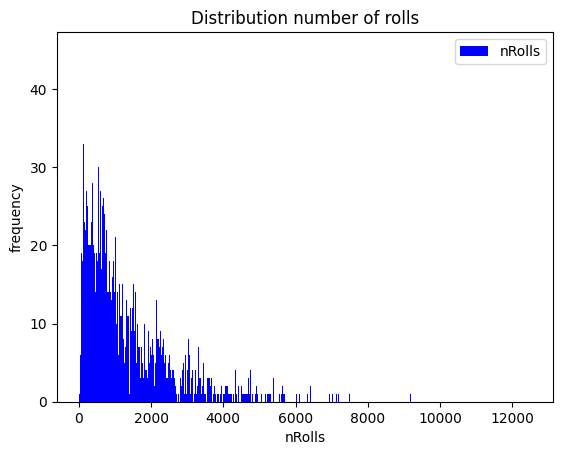

In [13]:
%matplotlib inline

plt.hist(nRolls, bins=len(set(nRolls)), facecolor='blue', label="nRolls")
plt.title("Distribution number of rolls")
plt.xlabel('nRolls')
plt.ylabel('frequency')
plt.legend()
#plt.show()